# Approche Classique 

In [ ]:
# Importation des bibliothèques nécessaires
import numpy as np
import matplotlib.pyplot as plt
import random
import cv2
import sys

# Pour l'évaluation des performances du modèle de classification
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

# Ajoute explicitement le dossier src au chemin Python
sys.path.append('../src')

# Importation des fonctions depuis le module local src/utils.py
from utils import (
    init_lists_0, 
    calculate_iou, 
    detect_buoy_robust,
    extraire_centres_par_couleur, 
    calculer_metriques_classif, 
    afficher_metriques_classif
)

# Assurer la reproduction des résultats
random.seed(42)

### Initialisation des listes

Pour nous simplifier la lecture des fichiers (images et labels), on crée une liste qui référence tous les chemins relatifs aux images selon l'arborescence et une autre liste qui prendra les contenus des textes associés aux images. Ils auront alors les mêmes indices.

In [ ]:
# Initialisation des listes
im_add, labels = init_lists_0()

# Vérification : On doit avoir 168 (sauf si on ne compte pas le fichier en .gif qui est illisible donc 167) adresses d'images et listes de labels 
print(f"On a {len(im_add)} adresses d'images et {len(labels)} listes de labels.")

# On créera une liste de cardinaux à partir des véritables étiquettes (GT_card) pour faciliter la lecture des résultats
dict_card_fr = {0: "EST", 1: "NORD", 2: "SUD", 3: "OUEST"} 
GT_card = [dict_card_fr[labels[k][0]] for k in range(len(im_add))]

On a 167 adresses d'images et 167 listes de labels.


### Détection : Pas à pas

Pour la détection de bouée via l'approche image, on s'inspirera de la segmentation couleur vu le semestre dernier dans le module "Couleurs" et nous appliquerons des opérations morphologiques simples vu dans le module "Advanced Image Analysis" du bloc "Image Science (1)".

Tout d'abord, on va convertir l'image en espace de couleur HSV pour mieux isoler les couleurs caractéristiques des bouées (jaune et noir). Ensuite, on appliquera des opérations morphologiques pour nettoyer le masque et enfin, on détectera les contours pour trouver la bounding box la plus adéquate de la bouée.

In [3]:
# Choix d'une image aléatoire ou pas
ALEATOIRE = False
if ALEATOIRE :
    c = random.randint(0, len(im_add) - 1)
else : c = 6

adresse_img, liste = im_add[c], labels[c]
print(f"On a choisi l'image numéro                  : {c}")

# Liste des coordonnées de type [xmin, ymin, xmax, ymax]
print(f"La bounding box de la bouée est situé en    : [xmin, ymin, xmax, ymax] = {liste[1:]}")
print(f"Le numéro du cardinal est                   : {liste[0]} (correspond à {dict_card_fr[liste[0]]})")

On a choisi l'image numéro                  : 6
La bounding box de la bouée est situé en    : [xmin, ymin, xmax, ymax] = [117, 47, 617, 909]
Le numéro du cardinal est                   : 0 (correspond à EST)


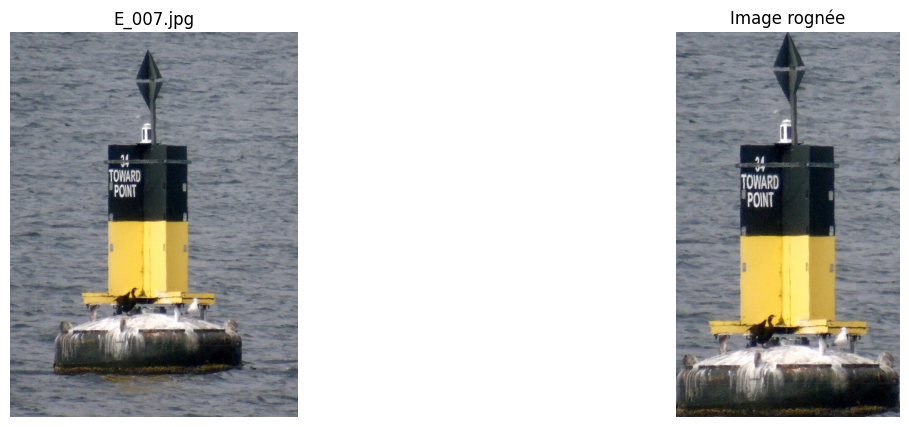

In [4]:
# Affectation de l'image originale et conversion en RGB pour l'affichage
img_orig = cv2.imread(adresse_img) 
img_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

# Recadrage de l'image
img_c = img_rgb[liste[2]:liste[4], liste[1]:liste[3]]

# Affichage des images
plt.figure(figsize=(15,5))
plt.subplot(121); plt.title(f"{adresse_img[28:]}"); plt.imshow(img_rgb); plt.axis('off')
plt.subplot(122); plt.imshow(img_c); plt.title(f"Image rognée"); plt.axis('off');

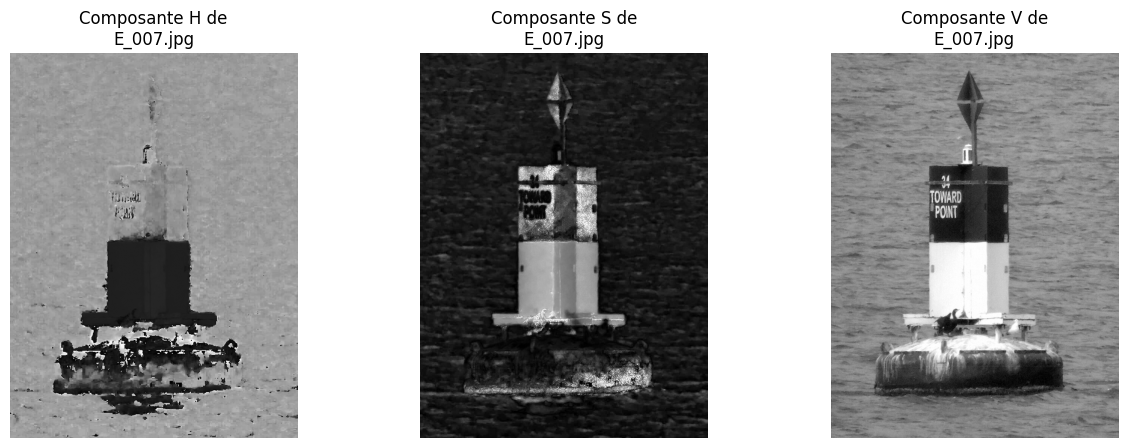

In [5]:
# Conversion de l'image rognée en HSV
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# Affichage des 3 composantes H, S, V de l'image rognée
H, S, V = img_hsv[:,:,0], img_hsv[:,:,1], img_hsv[:,:,2]

# Affichage des images
plt.figure(figsize=(15,5))
plt.subplot(131); plt.imshow(H, cmap = "gray"); plt.axis('off'); plt.title(f"Composante H de\n{adresse_img[28:]}");
plt.subplot(132); plt.imshow(S, cmap = "gray"); plt.axis('off'); plt.title(f"Composante S de\n{adresse_img[28:]}");
plt.subplot(133); plt.imshow(V, cmap = "gray"); plt.axis('off'); plt.title(f"Composante V de\n{adresse_img[28:]}");

In [6]:
# Initialisation de la taille de l'image
H, W, C = len(img_hsv[:,0,0]), len(img_hsv[0,:,:]), len(img_hsv[0,0,:])
print(f"Hauteur : {H}, Largeur : {W}, Canal : {C}")

Hauteur : 1024, Largeur : 764, Canal : 3


(np.float64(-0.5), np.float64(763.5), np.float64(1023.5), np.float64(-0.5))

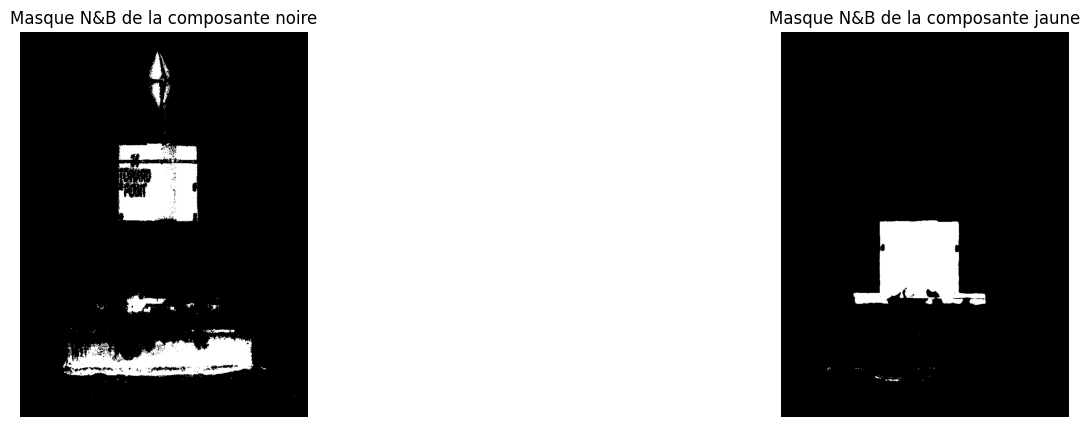

In [7]:
# Création manuelle du masque binaire pour les pixels jaunes
lower_yellow = np.array([15, 100, 100])
upper_yellow = np.array([35, 255, 255])
BW_yellow = cv2.inRange(img_hsv, lower_yellow, upper_yellow)

# Création manuelle du masque binaire pour les pixels noirs
lower_black = np.array([0, 0, 0])
upper_black = np.array([180, 255, 60])
BW_black = cv2.inRange(img_hsv, lower_black, upper_black)

# Affichage des images
plt.figure(figsize=(18,5))
plt.subplot(121); plt.imshow(BW_black, vmin = 0, vmax =1, cmap = 'gray');plt.axis('off'); plt.title("Masque N&B de la composante noire");
plt.subplot(122); plt.imshow(BW_yellow, cmap='gray'); plt.title("Masque N&B de la composante jaune");plt.axis('off')

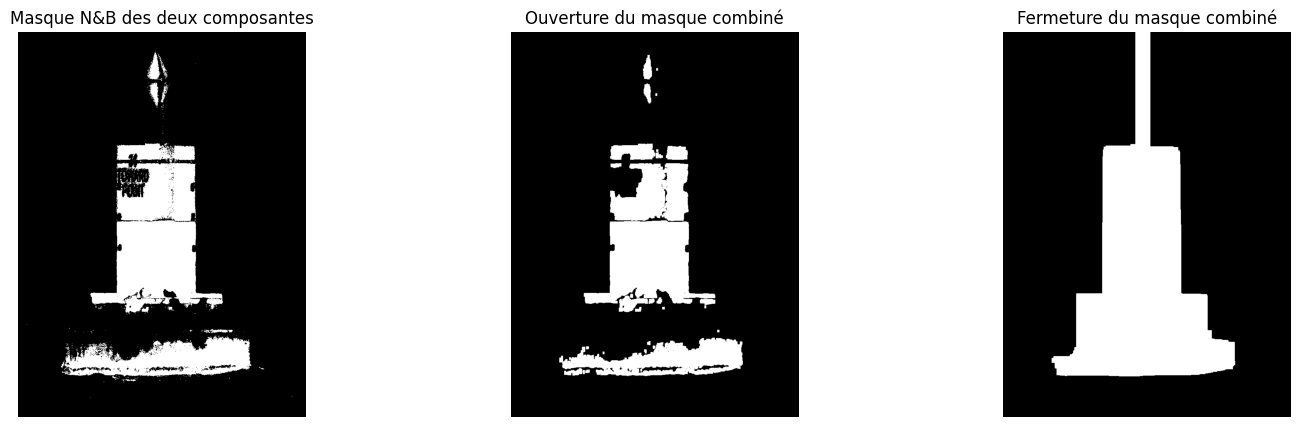

In [8]:
# On combine les deux masques pour n'avoir qu'une seule image binaire
combined = cv2.bitwise_or(BW_yellow, BW_black)

# On effectue une ouverture pour enlever les petits bruits (on prend un élément structurant de taille adaptée à la taille de l'image)
kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (W//140, H//130))
combined_opened = cv2.morphologyEx(combined, cv2.MORPH_OPEN, kernel_open)

# On effectue une fermeture pour remplir les petits trous (on prend un élément structurant de taille adaptée à la taille de l'image)
kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (W//9, H//5))
combined_closed = cv2.morphologyEx(combined_opened, cv2.MORPH_CLOSE, kernel_close)

# Affichage des images
plt.figure(figsize=(18,5))
plt.subplot(131); plt.imshow(combined, vmin = 0, vmax =1, cmap = 'gray'); plt.axis('off'); plt.title("Masque N&B des deux composantes");
plt.subplot(132); plt.imshow(combined_opened, vmin = 0, vmax =1, cmap = 'gray'); plt.axis('off'); plt.title("Ouverture du masque combiné");
plt.subplot(133); plt.imshow(combined_closed, vmin = 0, vmax =1, cmap = 'gray'); plt.axis('off'); plt.title("Fermeture du masque combiné");

In [9]:
# On trouve les contours sur l'image binaire nettoyée
contours, _ = cv2.findContours(combined_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# On vérifie s'il y a des contours trouvés, sinon on retourne une bounding box nulle
if not contours:
    pred_box = [0, 0, 0, 0]
else :
    valid_boxes = []
    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)
        aspect_ratio = bh / float(bw)
        if 1.5 < aspect_ratio < 8: # On vérifie que le rapport hauteur/largeur est cohérent avec une bouée
            valid_boxes.append((x, y, x + bw, y + bh, cv2.contourArea(cnt)))
    if valid_boxes:
        # On choisit la boîte englobante avec la plus grande aire parmi les boîtes valides
        best_box = max(valid_boxes, key=lambda x: x[4])
        pred_box = list(best_box[:4])
    else:
        # Si aucune boîte n'est valide, on prend la boîte englobante du contour avec la plus grande aire parmi tous les contours
        c_max = max(contours, key=cv2.contourArea)
        x, y, bw, bh = cv2.boundingRect(c_max)
    pred_box = [x, y, x + bw, y + bh]

print(f"Bounding box prédite : [xmin, ymin, xmax, ymax] = {pred_box}")

Bounding box prédite : [xmin, ymin, xmax, ymax] = [129, 0, 616, 916]


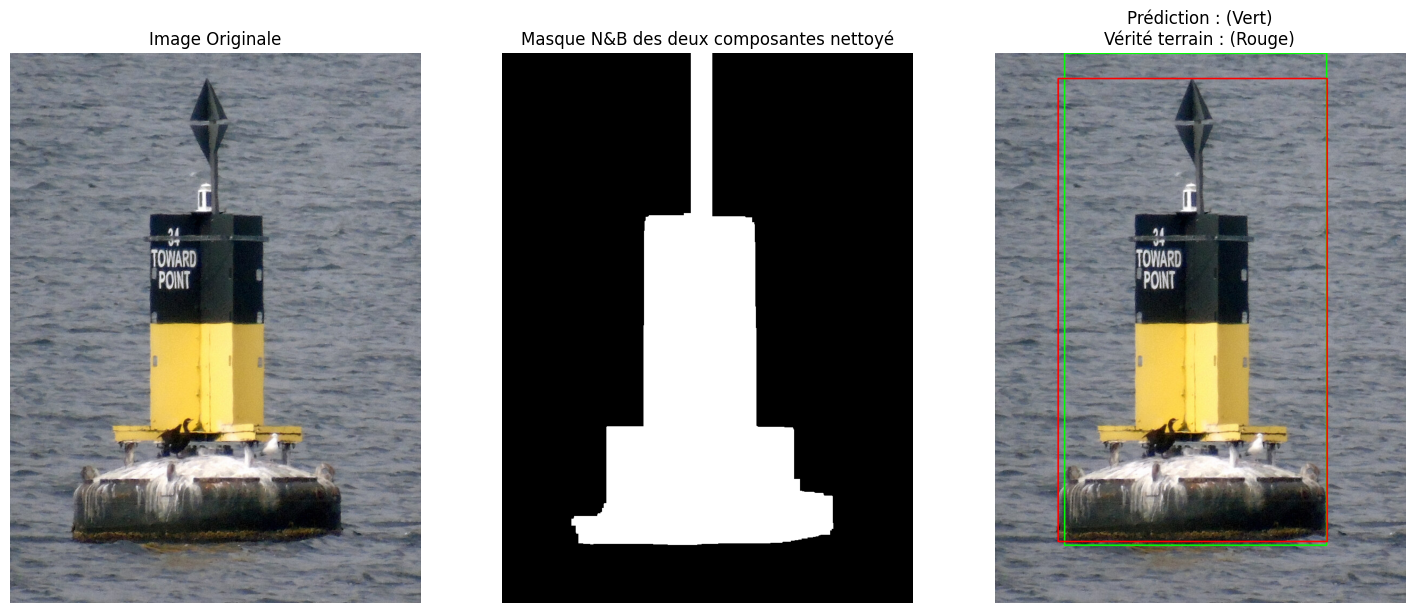

In [10]:
# On copie l'image originale pour dessiner les rectangles de la prédiction et du GT sans les superposer
res_img = img_rgb.copy()
cv2.rectangle(res_img, (pred_box[0], pred_box[1]), (pred_box[2], pred_box[3]), (0, 255, 0), 2)
cv2.rectangle(res_img, (liste[1], liste[2]), (liste[3], liste[4]), (255, 0, 0), 2)

plt.figure(figsize=(18, 8))
plt.subplot(1, 3, 1); plt.imshow(img_rgb); plt.title("Image Originale"); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(combined_closed, cmap='gray'); plt.title("Masque N&B des deux composantes nettoyé"); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(res_img); plt.title("Prédiction : (Vert)\nVérité terrain : (Rouge)"); plt.axis('off')
plt.show()

### Statistiques de la détection

On calcule dans cette partie les métriques liées à la détection c'est-à-dire la moyenne des IoU de chaque image où l'IoU est définie par 
$$ IoU = \frac{\text{Intersection des aires des bounding boxes}}{\text{Union des aires des bounding boxes}} $$

Au lieu de calculer le mAP (mean Average Precision), nous calculons le mAP @ 50 que l'on va définir de façon plus facile par : $$ \text{mAP @ 0.50} = \frac{1}{N} \sum_{i = 1}^{N} \mathbb{1}_{\text{IoU}_i > 0.5} $$ 

In [12]:
# On évalue les performances de notre algorithme sur l'ensemble du dataset
all_ious = [calculate_iou(detect_buoy_robust(im_add[i]), labels[i][1:]) for i in range(len(im_add))]
print(f"\nMétriques calculée sur {len(im_add)} images:")
print(f"Mean IoU: {np.mean(all_ious):.4f}")
print(f"mAP @ 0.5: {np.mean([1 if iou > 0.5 else 0 for iou in all_ious]):.4f}")


Métriques calculée sur 167 images:
Mean IoU: 0.5991
mAP @ 0.5: 0.6886


Ce score est très satisfaisant car il prend en compte toutes les fois où les bounding boxes prédites sont en dehors des vraies (IoU = 0) et arrive quand même à atteindre presque 60% d'IoU moyenne. On peut visualiser la prédiction d'une bounding box et sa similarité avec la vérité terrain avec la cellule suivante.

Test de détection sur l'image index 6 : ../datasets/dataset1/images/E_007.jpg


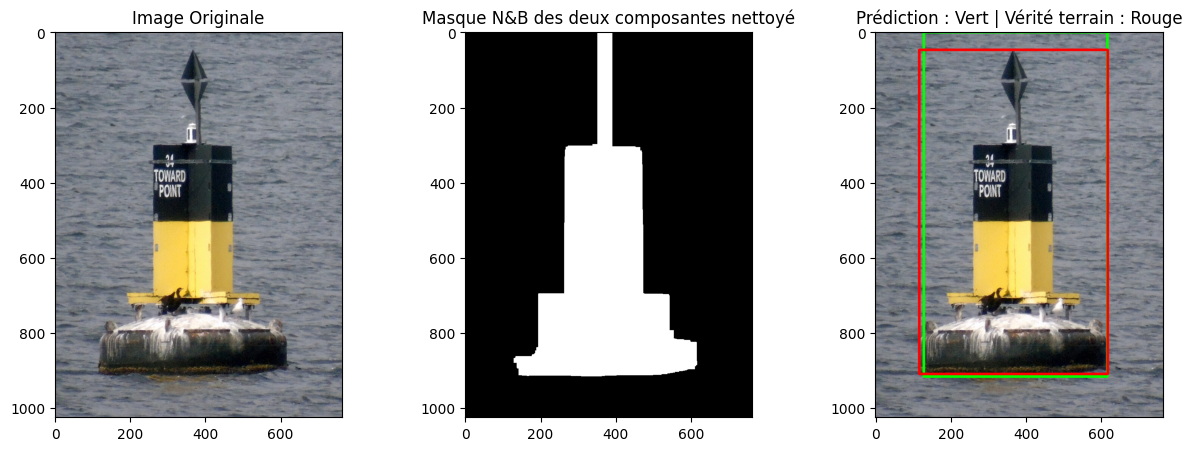

IoU pour cette image : 0.9181


In [13]:
# Cellule de test pour visualiser les étapes de détection avec une image aléatoire ou pas
ALEATOIRE = False
if ALEATOIRE :
    test_index = random.randint(0, len(im_add) - 1)
else : test_index = 6

adresse_test = im_add[test_index]
liste_test = labels[test_index]
gt_test = liste_test[1:]

print(f"Test de détection sur l'image index {test_index} : {adresse_test}")
pred_test = detect_buoy_robust(adresse_test, visualize=True, gt_box=gt_test)

iou_test = calculate_iou(pred_test, gt_test)
print(f"IoU pour cette image : {iou_test:.4f}")

### Classification : Pas à pas

Pour la classification, nous partons de l'image déjà rognée grâce aux bounding boxes déjà annotées dans le dataset pour nous concentrer sur la tâche de classification.

Pour la classification de bouée via l'approche image, on s'inspirera aussi de la segmentation couleur vu le semestre dernier dans le module "Couleurs" et nous appliquerons des opérations morphologiques simples vu dans le module "Advanced Image Analysis" du bloc "Image Science (1)".

Tout d'abord, on va convertir l'image en espace de couleur HSV pour mieux isoler les couleurs caractéristiques des bouées (jaune et noir). Ensuite, on appliquera des opérations morphologiques pour nettoyer le masque puis on fera une transformation du masque pour étudier l'ordre de l'occurence des pixels noirs et des pixels jaunes afin de conclure sur les séquences d'où les cardinaux.

(np.float64(-0.5), np.float64(499.5), np.float64(861.5), np.float64(-0.5))

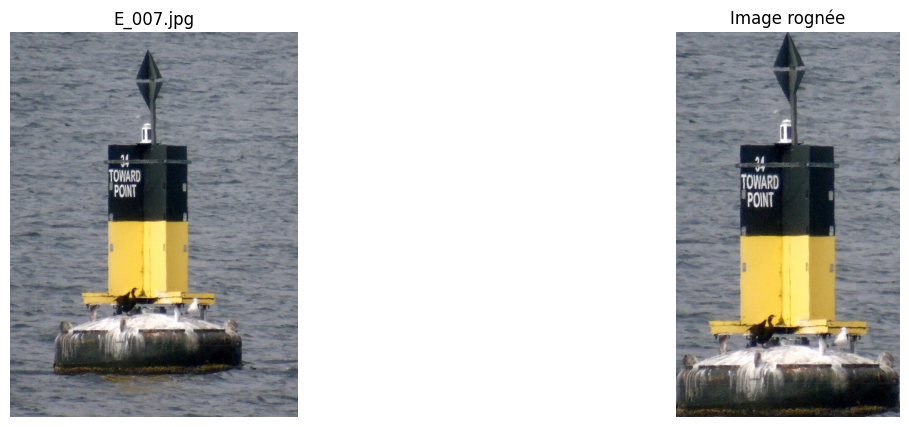

In [14]:
# Affectation de l'image originale et conversion en RGB pour l'affichage
img_orig = cv2.imread(adresse_img) 
img_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

# Recadrage de l'image
img_c = img_rgb[liste[2]:liste[4], liste[1]:liste[3]]

# Affichage des images
plt.figure(figsize=(15,5))
plt.subplot(121); plt.title(f"{adresse_img[28:]}"); plt.imshow(img_rgb); plt.axis('off')
plt.subplot(122); plt.imshow(img_c); plt.title(f"Image rognée"); plt.axis('off')

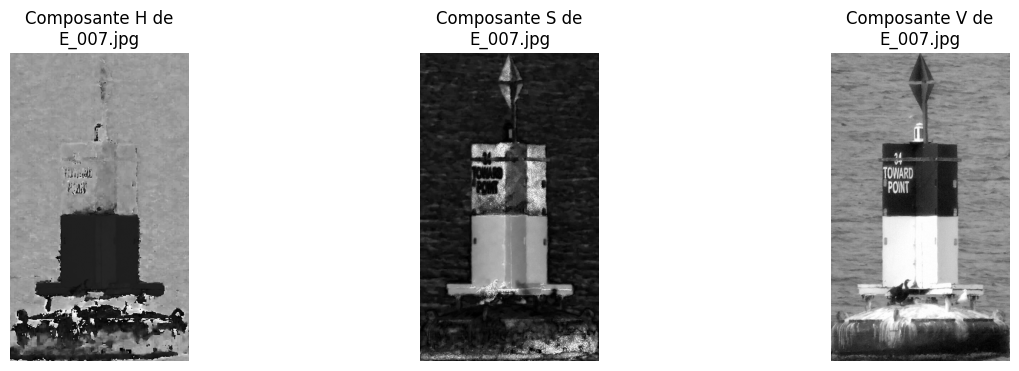

In [15]:
# Conversion de l'image rognée en HSV
img_hsv = cv2.cvtColor(img_c, cv2.COLOR_RGB2HSV)

# Affichage des 3 composantes H, S, V de l'image rognée
H, S, V = img_hsv[:,:,0], img_hsv[:,:,1], img_hsv[:,:,2]

# Affichage des images
plt.figure(figsize=(15,4))
plt.subplot(131); plt.imshow(H, cmap = "gray"); plt.axis('off'); plt.title(f"Composante H de\n{adresse_img[28:]}");
plt.subplot(132); plt.imshow(S, cmap = "gray"); plt.axis('off'); plt.title(f"Composante S de\n{adresse_img[28:]}");
plt.subplot(133); plt.imshow(V, cmap = "gray"); plt.axis('off'); plt.title(f"Composante V de\n{adresse_img[28:]}");

In [16]:
# Initialisation de la taille de l'image
H, W, C = len(img_hsv[:,0,0]), len(img_hsv[0,:,:]), len(img_hsv[0,0,:])
print(f"Hauteur : {H}, Largeur : {W}, Canal : {C}")

Hauteur : 862, Largeur : 500, Canal : 3


(np.float64(-0.5), np.float64(499.5), np.float64(861.5), np.float64(-0.5))

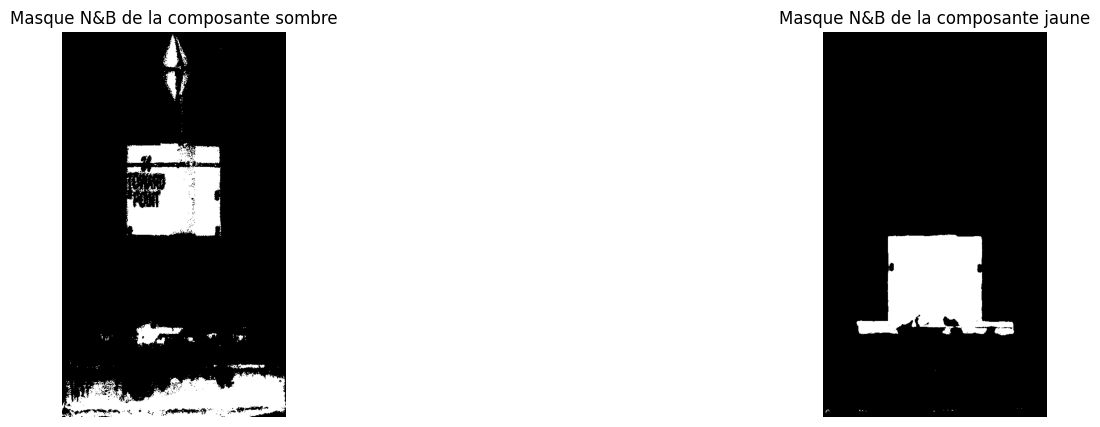

In [17]:
# Création manuelle du masque binaire pour les pixels jaunes
lower_yellow = np.array([15, 100, 100])
upper_yellow = np.array([35, 255, 255])
BW_yellow = cv2.inRange(img_hsv, lower_yellow, upper_yellow)

# Création manuelle du masque binaire pour les pixels noirs
lower_black = np.array([0, 0, 0])
upper_black = np.array([180, 255, 60])
BW_black = cv2.inRange(img_hsv, lower_black, upper_black)

# Affichage des images
plt.figure(figsize=(18,5))
plt.subplot(121); plt.imshow(BW_black, vmin = 0, vmax =1, cmap = 'gray'); plt.axis('off'); plt.title("Masque N&B de la composante sombre");
plt.subplot(122); plt.imshow(BW_yellow, cmap='gray'); plt.title("Masque N&B de la composante jaune");plt.axis('off')

(np.float64(-0.5), np.float64(499.5), np.float64(861.5), np.float64(-0.5))

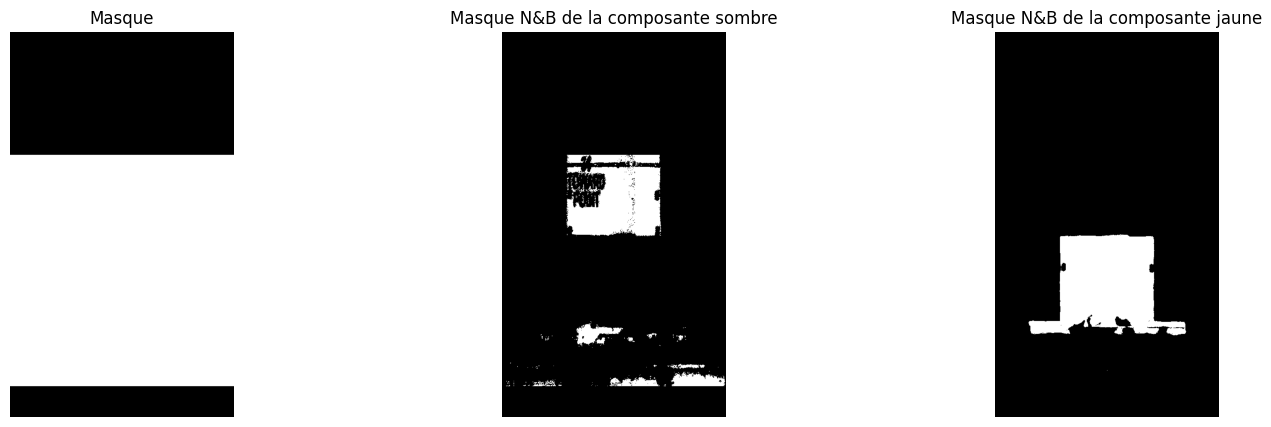

In [18]:
# On crée un masque pour enlever le haut de l'image pour retirer le noir du cône et le bas de l'image pour retirer des potentiels éléments parasites
mask_cone = np.zeros((H, W))
seuil_sup = int(0.32*H);
seuil_inf = int(0.92*H);
mask_cone[seuil_sup:seuil_inf,:] = 255;
mask_cone = mask_cone.astype(np.uint8)

# Application du masque
BW_black = cv2.bitwise_and(BW_black, mask_cone)
BW_yellow = cv2.bitwise_and(BW_yellow, mask_cone)

# Affichage des images
plt.figure(figsize=(18,5))
plt.subplot(131); plt.imshow(mask_cone, cmap = "gray"); plt.title("Masque");plt.axis('off')
plt.subplot(132); plt.imshow(BW_black, vmin = 0, vmax =1, cmap = 'gray');plt.axis('off'); plt.title("Masque N&B de la composante sombre");
plt.subplot(133); plt.imshow(BW_yellow, cmap='gray'); plt.title("Masque N&B de la composante jaune");plt.axis('off')

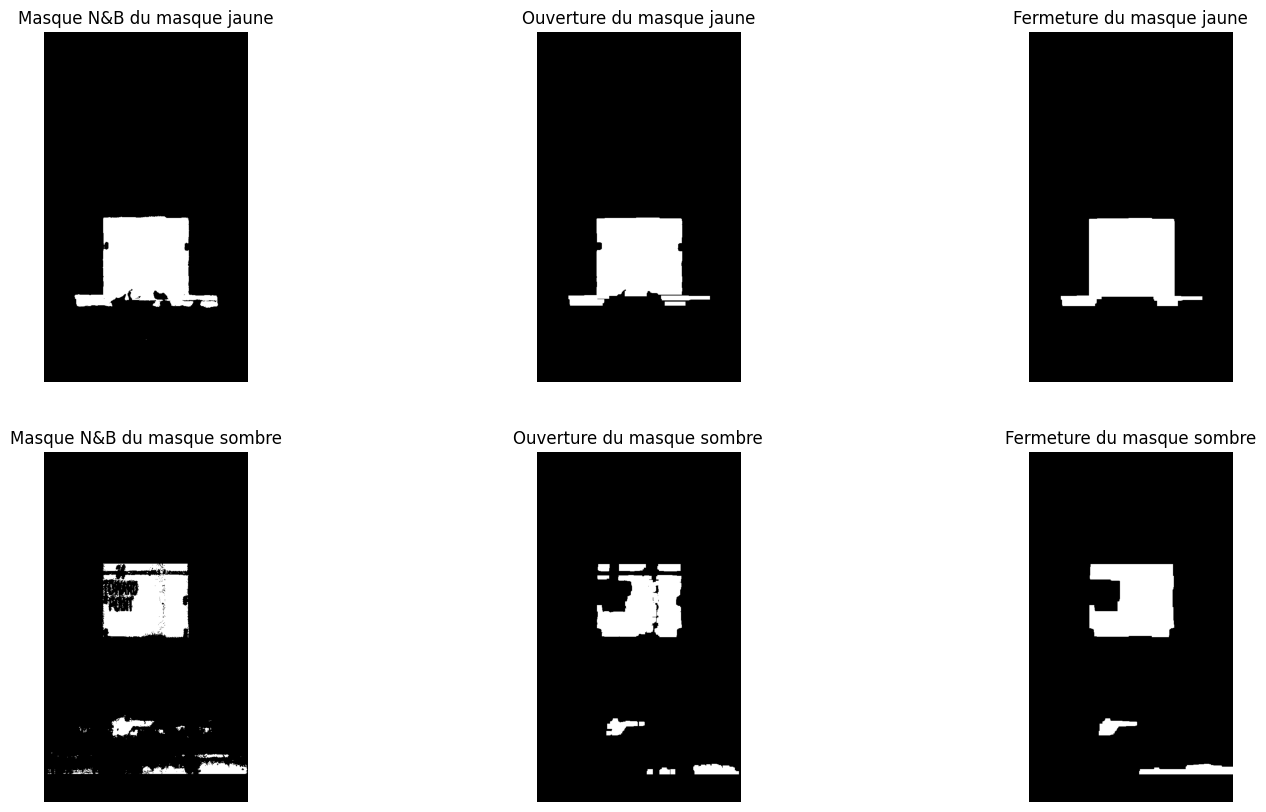

In [19]:
# Cette fois-ci, on ne combine pas les masques avant de faire les opérations morphologiques pour mieux visualiser les étapes de nettoyage de chaque composante

# On effectue une ouverture pour enlever les petits bruits (on prend un élément structurant de taille adaptée à la taille de l'image)
H0y, W0y = max(H//100, 1), max(W//10, 1) # On s'assure que l'élément structurant ne soit pas plus grand que l'image
kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (W0y, H0y))
BW_yellow_opened = cv2.morphologyEx(BW_yellow, cv2.MORPH_OPEN, kernel_open)
# On effectue une fermeture pour remplir les petits trous (on prend un élément structurant de taille adaptée à la taille de l'image)
H1y, W1y = max(H//10, 1), max(W//5, 1) # On s'assure que l'élément structurant ne soit pas plus grand que l'image
kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (W1y, H1y))
BW_yellow_closed = cv2.morphologyEx(BW_yellow_opened, cv2.MORPH_CLOSE, kernel_close)

# On effectue une ouverture pour enlever les petits bruits (on prend un élément structurant de taille adaptée à la taille de l'image)
H0b, W0b = max(H//100, 1), max(W//50, 1) # On s'assure que l'élément structurant ne soit pas plus grand que l'image
kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (W0b, H0b))
BW_black_opened = cv2.morphologyEx(BW_black, cv2.MORPH_OPEN, kernel_open)
# On effectue une fermeture pour remplir les petits trous (on prend un élément structurant de taille adaptée à la taille de l'image)
H1b, W1b = max(H//20, 1), max(W//10, 1) # On s'assure que l'élément structurant ne soit pas plus grand que l'image
kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (W1b, H1b))
BW_black_closed = cv2.morphologyEx(BW_black_opened, cv2.MORPH_CLOSE, kernel_close)


# Affichage des images
plt.figure(figsize=(18,10))
plt.subplot(231); plt.imshow(BW_yellow, vmin = 0, vmax =1, cmap = 'gray'); plt.axis('off'); plt.title("Masque N&B du masque jaune");
plt.subplot(232); plt.imshow(BW_yellow_opened, vmin = 0, vmax =1, cmap = 'gray'); plt.axis('off'); plt.title("Ouverture du masque jaune");
plt.subplot(233); plt.imshow(BW_yellow_closed, vmin = 0, vmax =1, cmap = 'gray'); plt.axis('off'); plt.title("Fermeture du masque jaune");

plt.subplot(234); plt.imshow(BW_black, vmin = 0, vmax =1, cmap = 'gray');plt.axis('off'); plt.title("Masque N&B du masque sombre");
plt.subplot(235); plt.imshow(BW_black_opened, vmin = 0, vmax =1, cmap = 'gray'); plt.axis('off'); plt.title("Ouverture du masque sombre");
plt.subplot(236); plt.imshow(BW_black_closed, vmin = 0, vmax =1, cmap = 'gray'); plt.axis('off'); plt.title("Fermeture du masque sombre");

(np.float64(-0.5), np.float64(499.5), np.float64(861.5), np.float64(-0.5))

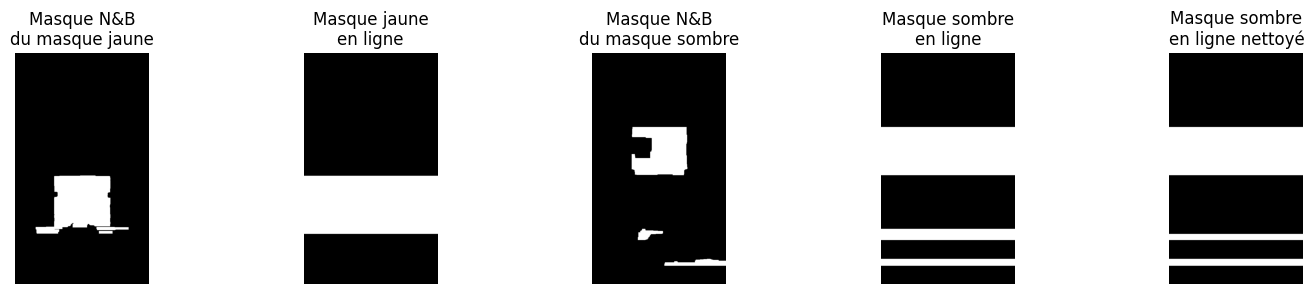

In [20]:
# On garde les informations de hauteur des pixels jaunes et noirs pour faire des lignes de chaque composante
line = cv2.getStructuringElement(cv2.MORPH_RECT, (2*W, 1))
BW_yellow_line = cv2.morphologyEx(BW_yellow_closed, cv2.MORPH_DILATE, line)
BW_black_line = cv2.morphologyEx(BW_black_closed, cv2.MORPH_DILATE, line)

# On enlève les pixels jaunes du masque sombre pour ne garder que les pixels noirs
BW_black_line_no_yellow = cv2.bitwise_and(BW_black_line, cv2.bitwise_not(BW_yellow_line))

# Affichage des images
plt.figure(figsize=(18,3))
plt.subplot(151); plt.imshow(BW_yellow_opened, vmin = 0, vmax =1, cmap = 'gray'); plt.title("Masque N&B\ndu masque jaune");plt.axis('off')
plt.subplot(152); plt.imshow(BW_yellow_line, vmin = 0, vmax =1, cmap = 'gray'); plt.title("Masque jaune\nen ligne");plt.axis('off')
plt.subplot(153); plt.imshow(BW_black_closed, vmin = 0, vmax =1, cmap = 'gray');plt.title("Masque N&B\ndu masque sombre");plt.axis('off')
plt.subplot(154); plt.imshow(BW_black_line, vmin = 0, vmax =1, cmap = 'gray'); plt.title("Masque sombre\nen ligne");plt.axis('off')
plt.subplot(155); plt.imshow(BW_black_line_no_yellow, vmin = 0, vmax =1, cmap = 'gray'); plt.title("Masque sombre\nen ligne nettoyé");plt.axis('off')

Séquence de couleurs détectée : ['NOIR', 'JAUNE', 'NOIR']
Cardinal détecté : EST
Cardinal vérité terrain : EST


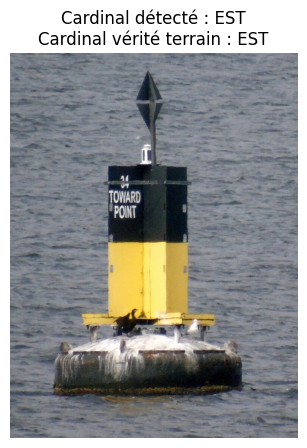

In [21]:
# Extraction des centres des amas noirs et jaunes
centres = []
centres += extraire_centres_par_couleur(BW_black_line_no_yellow, "NOIR", min_area=1) # On peut ajuster le seuil de surface minimale pour les noirs et les jaunes en fonction de la taille des amas
centres += extraire_centres_par_couleur(BW_yellow_line, "JAUNE")

# Tri vertical du haut vers le bas
centres.sort(key=lambda t: t[0])

# Construction de la séquence de couleurs sans doublons consécutifs
sequence = []
for _, couleur, _ in centres:
    if not sequence or sequence[-1] != couleur:
        sequence.append(couleur)

# On garde au plus les 3 premiers éléments utiles
sequence = sequence[:3]

# Correspondance séquence -> cardinal
if sequence == ['NOIR', 'JAUNE']: resultat = "NORD"
elif sequence == ['JAUNE', 'NOIR']: resultat = "SUD"
elif sequence == ['NOIR', 'JAUNE', 'NOIR']: resultat = "EST"
elif sequence == ['JAUNE', 'NOIR', 'JAUNE']: resultat = "OUEST"
else : resultat = "NORD" # En cas de séquence inconnue, on choisit la classe majoritaire (NORD) pour essayer d'avoir au moins une bonne prédiction plutôt que de classer comme Inconnu

print(f"Séquence de couleurs détectée : {sequence}")
print(f"Cardinal détecté : {resultat}")
print(f"Cardinal vérité terrain : {dict_card_fr[liste[0]]}")

# Affectation de l'image originale et conversion en RGB pour l'affichage
img_orig = cv2.imread(adresse_img) 

# Affichage des images
plt.figure(figsize=(15,5))
plt.title(f"Cardinal détecté : {resultat}\nCardinal vérité terrain : {dict_card_fr[liste[0]]}"); 
plt.imshow(img_rgb); 
plt.axis('off');


### Statistiques de la classification

On calcule dans cette partie les métriques usuelles liées à la classification définies par :
$$ \text{Precision} = \frac{\text{TP}}{\text{TP}+\text{FP}} $$
$$ \text{Recall} = \frac{\text{TP}}{\text{TP}+\text{FN}} $$
$$ \text{F1-Score} = \frac{2}{\frac{1}{\text{Precision}}+\frac{1}{\text{Recall}}} $$
$$ \text{Accuracy} = \frac{\text{TP}+\text{TN}}{\text{TP}+\text{TN}+\text{FP}+\text{FN}} $$


Programme pour calculer les statistiques (ce sont les mêmes que pour la section "pas à pas", on effectue les mêmes opérations mais sur toutes les images).

In [ ]:
BONS, MAUVAIS = [], []
dico_stats = {f"{gt}_{pred}": 0 for pred in ["EST", "NORD", "SUD", "OUEST"] for gt in ["EST", "NORD", "SUD", "OUEST"]}

# Initialisation des listes
im_add, labels = init_lists_0()

# On créera une liste de cardinaux à partir des véritables étiquettes (GT_card) pour faciliter la lecture des résultats
dict_card_fr = {0: "EST", 1: "NORD", 2: "SUD", 3: "OUEST"} 
GT_card = [dict_card_fr[labels[k][0]] for k in range(len(im_add))]

for c in range(len(im_add)):
    # Choix d'une image
    adresse_img, liste = im_add[c], labels[c]

    # Affectation de l'image originale et conversion en RGB pour l'affichage
    img_orig = cv2.imread(adresse_img) 
    img_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

    # Recadrage de l'image
    img_c = img_rgb[liste[2]:liste[4], liste[1]:liste[3]]

    # Conversion de l'image rognée en HSV
    img_hsv = cv2.cvtColor(img_c, cv2.COLOR_RGB2HSV)

    H, W, C = len(img_hsv[:,0,0]), len(img_hsv[0,:,:]), len(img_hsv[0,0,:])

    # Création manuelle du masque binaire pour les pixels jaunes
    lower_yellow = np.array([15, 100, 100])
    upper_yellow = np.array([35, 255, 255])
    BW_yellow = cv2.inRange(img_hsv, lower_yellow, upper_yellow)

    # Création manuelle du masque binaire pour les pixels noirs
    lower_black = np.array([0, 0, 0])
    upper_black = np.array([180, 255, 60])
    BW_black = cv2.inRange(img_hsv, lower_black, upper_black)

    # On crée un masque pour enlever le haut de l'image pour retirer le noir du cône et le bas de l'image pour retirer des potentiels éléments parasites
    mask_cone = np.zeros((H, W))
    seuil_sup = int(0.32*H);
    seuil_inf = int(0.92*H);
    mask_cone[seuil_sup:seuil_inf,:] = 255;
    mask_cone = mask_cone.astype(np.uint8)

    # Application du masque
    BW_black = cv2.bitwise_and(BW_black, mask_cone)
    BW_yellow = cv2.bitwise_and(BW_yellow, mask_cone)

    # On effectue une ouverture pour enlever les petits bruits (on prend un élément structurant de taille adaptée à la taille de l'image)
    H0y, W0y = max(H//100, 1), max(W//50, 1) # On s'assure que l'élément structurant ne soit pas plus grand que l'image
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (W0y, H0y))
    BW_yellow_opened = cv2.morphologyEx(BW_yellow, cv2.MORPH_OPEN, kernel_open)
    # On effectue une fermeture pour remplir les petits trous (on prend un élément structurant de taille adaptée à la taille de l'image)
    H1y, W1y = max(H//10, 1), max(W//5, 1) # On s'assure que l'élément structurant ne soit pas plus grand que l'image
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (W1y, H1y))
    BW_yellow_closed = cv2.morphologyEx(BW_yellow_opened, cv2.MORPH_CLOSE, kernel_close)

    # On effectue une ouverture pour enlever les petits bruits (on prend un élément structurant de taille adaptée à la taille de l'image)
    H0b, W0b = max(H//100, 1), max(W//50, 1) # On s'assure que l'élément structurant ne soit pas plus grand que l'image
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (W0b, H0b))
    BW_black_opened = cv2.morphologyEx(BW_black, cv2.MORPH_OPEN, kernel_open)
    # On effectue une fermeture pour remplir les petits trous (on prend un élément structurant de taille adaptée à la taille de l'image)
    H1b, W1b = max(H//20, 1), max(W//10, 1) # On s'assure que l'élément structurant ne soit pas plus grand que l'image
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (W1b, H1b))
    BW_black_closed = cv2.morphologyEx(BW_black_opened, cv2.MORPH_CLOSE, kernel_close)

    # On garde les informations de hauteur des pixels jaunes et noirs pour faire des lignes de chaque composante
    line = cv2.getStructuringElement(cv2.MORPH_RECT, (2*W, 1))
    BW_yellow_line = cv2.morphologyEx(BW_yellow_closed, cv2.MORPH_DILATE, line)
    BW_black_line = cv2.morphologyEx(BW_black_closed, cv2.MORPH_DILATE, line)

    # On enlève les pixels jaunes du masque sombre pour ne garder que les pixels noirs
    BW_black_line_no_yellow = cv2.bitwise_and(BW_black_line, cv2.bitwise_not(BW_yellow_line))

    # Extraction des centres des amas noirs et jaunes
    centres = []
    centres += extraire_centres_par_couleur(BW_black_line_no_yellow, "NOIR", min_area=H*W//10000)
    centres += extraire_centres_par_couleur(BW_yellow_line, "JAUNE", min_area=H*W//10000)

    # Tri vertical du haut vers le bas
    centres.sort(key=lambda t: t[0])

    # Construction de la séquence de couleurs sans doublons consécutifs
    sequence = []
    for _, couleur, _ in centres:
        if not sequence or sequence[-1] != couleur:
            sequence.append(couleur)

    # On garde au plus les 3 premiers éléments utiles
    sequence = sequence[:3]

    # Correspondance séquence -> cardinal
    if sequence == ['NOIR', 'JAUNE']: resultat = "NORD"
    elif sequence == ['JAUNE', 'NOIR']: resultat = "SUD"
    elif sequence == ['NOIR', 'JAUNE', 'NOIR']: resultat = "EST"
    elif sequence == ['JAUNE', 'NOIR', 'JAUNE']: resultat = "OUEST"
    else: 
        resultat = "NORD" # En cas de séquence inconnue, on choisit la classe majoritaire (NORD) pour essayer d'avoir au moins une bonne prédiction plutôt que de classer comme Inconnu


    if GT_card[c] == resultat :
        BONS.append(c)
    else :
        MAUVAIS.append(c)

    # Dictionnaire de statistiques où les clés sont de type "VéritéTerrain_Prediction" pour créer un tableau avec Accuracy, Precision, Recall, and F1-score.
    dico_stats[f"{GT_card[c]}_{resultat}"] += 1

metriques = calculer_metriques_classif(dico_stats)
afficher_metriques_classif(metriques)

# Affichage des détails des statistiques ou non
STATS = False
if STATS :
    print("Les bonnes balises sont : ", BONS)
    print("Les mauvaises balises sont : ", MAUVAIS)
    print("\nDictionnaire de statistiques : ", dico_stats)

--- MÉTROLOGIE GLOBALE ---
Accuracy globale: 79.64%

--- MÉTROLOGIE PAR CLASSE ---
Classe OUEST :
  Précision : 92.86%
  Rappel    : 76.47%
  F1-score  : 83.87%
  Accuracy  : 94.01%
  (Détails  : TP=26, FP=2, FN=8)

Classe NORD :
  Précision : 83.64%
  Rappel    : 77.97%
  F1-score  : 80.70%
  Accuracy  : 86.83%
  (Détails  : TP=46, FP=9, FN=13)

Classe EST :
  Précision : 59.26%
  Rappel    : 86.49%
  F1-score  : 70.33%
  Accuracy  : 83.83%
  (Détails  : TP=32, FP=22, FN=5)

Classe SUD :
  Précision : 96.67%
  Rappel    : 78.38%
  F1-score  : 86.57%
  Accuracy  : 94.61%
  (Détails  : TP=29, FP=1, FN=8)



Les résultats sont très satisfaisants et surtout grâce à l'opération de dilatation de l'image avec un élément structurant ligne qui permet de prendre en compte seulement la hauteur des pixels et pas seulement de leur aire : l'accuracy globale a fait un bond de 60% à presque 80% avec cette opération.

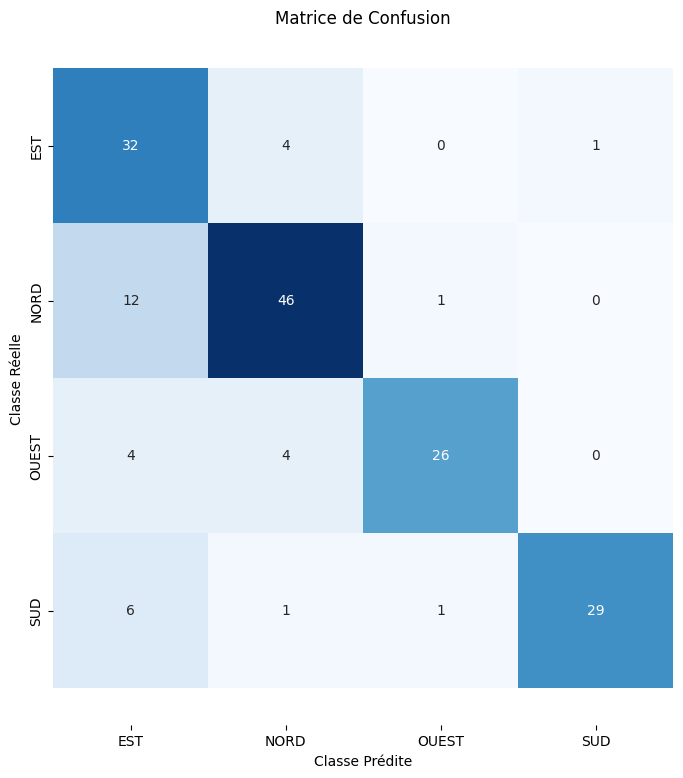

In [ ]:
# Extraction des classes uniques à partir des clés du dictionnaire de statistiques
classes = sorted(list(set(k.split('_')[0] for k in dico_stats.keys()) | set(k.split('_')[1] for k in dico_stats.keys())))

# Préparation des listes pour les étiquettes réelles et prédites
y_true = []
y_pred = []

for key, count in dico_stats.items():
    gt, pred = key.split('_')
    y_true.extend([gt] * count)
    y_pred.extend([pred] * count)

# Calcul de la matrice de confusion
cm = confusion_matrix(y_true, y_pred, labels=classes)

# Conversion en DataFrame pour une meilleure visualisation avec seaborn
cm_df = pd.DataFrame(cm, index=classes, columns=classes)

# Affichage de la matrice de confusion
plt.figure(figsize=(8, 9))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matrice de Confusion')
plt.xlabel('Classe Prédite')
plt.ylabel('Classe Réelle')
plt.axis('equal')
plt.show()